In [1]:
import pandas as pd

xls = pd.read_excel(
    'ParleysRWIS_20211101-20230430.xlsx',
    sheet_name=['RwisAtmosphericData', 'RwisSurfaceData'],
    parse_dates=['SampleTime'],    # ← ensure this column is parsed as full datetime
    engine='openpyxl'
)

df1 = xls['RwisAtmosphericData']
df2 = xls['RwisSurfaceData']

# merge
df1['SampleTime'] = pd.to_datetime(df1['SampleTime'])
df2['SampleTime'] = pd.to_datetime(df2['SampleTime'])

df1['RwisControllerIntId'] = df1['RwisControllerIntId'].astype(str)
df2['RwisControllerIntId'] = df2['RwisControllerIntId'].astype(str)

df_merged = pd.merge(
    df1,
    df2,
    on=['SampleTime', 'RwisControllerIntId'],
    how='inner',
    suffixes=('_atm','_surf')
)



In [2]:
cols_to_drop = ['Pressure', 'SnowIntervalDepth', 'PrecipitationIntervalAmount','PrecipitationAmount',
                'RoadStatusText','iceCurCondIndex','iceAvgCondIndex','iceCurCondCode','iceAvgCondCode',
               'iceCurFricIndex','iceAvgFricIndex','iceCurFricCode','iceAvgFricCode','iceGrip','iceXValue',
               'iceYValue','iceYXRatio','iceLens','SurfaceSensorError','SurfaceSalinity','SurfaceFreezePoint','RoadStatus',
               'RoadStatus','RoadTemp','iceRoadTemp','RwisAtmoEquipmentIntId','WindSpeedGustTimestamp',
               'RwisSurfaceEquipmentIntId','WindDirection','WindSpeedAverage','WindSpeedGust','Visibility',
                'BatteryVoltage','dstInputVoltage','dstHardwareStatus','SurfaceStatusText','dscRoadStatusText','SubSurfaceTemp',
               'AirTemp_atm','DewPoint_atm','RelativeHumidity_atm','dscLevelOfGrip','dstRoadTemp'] 
df_merged_1 = df_merged.drop(columns=cols_to_drop)
df_merged_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 510142 entries, 0 to 510141
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              510142 non-null  datetime64[ns]
 1   RwisControllerIntId     510142 non-null  object        
 2   PrecipitationIntensity  45706 non-null   object        
 3   SnowDepth               115089 non-null  float64       
 4   SolarRadiation          434049 non-null  float64       
 5   PrecipitationType       508441 non-null  object        
 6   WetBulbTemp             509154 non-null  float64       
 7   SnowfallRate            510142 non-null  float64       
 8   WinterRoadWeatherIndex  503682 non-null  float64       
 9   RainTotal               510142 non-null  float64       
 10  StormIntensityIndex     500135 non-null  float64       
 11  PerformanceMetric       503605 non-null  float64       
 12  SurfaceStatus           506373

<AxesSubplot:>

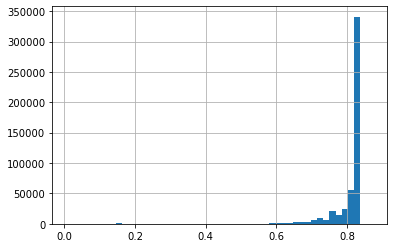

In [3]:
# Cell 4: histograms for all numeric columns
import matplotlib.pyplot as plt
%matplotlib inline

# Remove rows where PrecipitationIntensity is 'fog'
df_merged_1 = df_merged_1[df_merged_1['PrecipitationIntensity'] != 'fog']
# Remove rows where WetBulbTemp < -100
df_merged_1 = df_merged_1[df_merged_1['WetBulbTemp'] >= -100]
df_merged_1 = df_merged_1[df_merged_1['SurfaceTemp'] < 200]
df_merged_1 = df_merged_1[df_merged_1['AirTemp_surf'] < 100]
df_merged_1 = df_merged_1[df_merged_1['DewPoint_surf'] < 80]
df_merged_1 = df_merged_1[df_merged_1['DewPoint_surf'] > -20]
df_merged_1 = df_merged_1[df_merged_1['dscSurfStatus'] < 10]
df_merged_1 = df_merged_1.fillna(df_merged_1.mean(numeric_only=True))

df_merged_1 = df_merged_1[
    (df_merged_1['SurfaceGrip'] >= 0) &
    (df_merged_1['SurfaceGrip'] <= 1)
].reset_index(drop=True)


df_merged_1['SurfaceGrip'].hist(bins=50)
# Show all value counts for SnowfallRate
# print(df_merged_1['SnowfallRate'].value_counts(dropna=False, sort=True).to_string())
# print(df_merged_1['dscSurfStatus'].value_counts(dropna=False, sort=True).to_string())

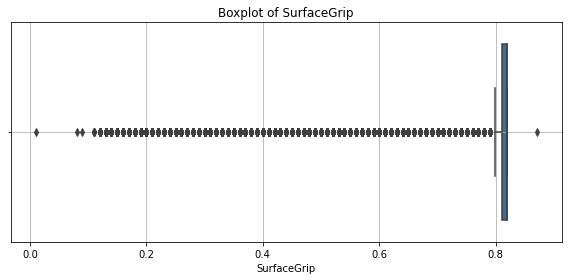

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_merged_1['SurfaceGrip'])
plt.title("Boxplot of SurfaceGrip")
plt.xlabel("SurfaceGrip")
plt.grid(True)
plt.tight_layout()
plt.show()


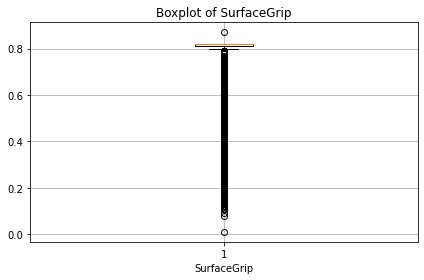

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_merged_1['SurfaceGrip'].dropna())
plt.title("Boxplot of SurfaceGrip")
plt.xlabel("SurfaceGrip")
plt.grid(True)
plt.tight_layout()
plt.show()


## make sure time_diff is the same

In [6]:
df_merged_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497854 entries, 0 to 497853
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              497854 non-null  datetime64[ns]
 1   RwisControllerIntId     497854 non-null  object        
 2   PrecipitationIntensity  44933 non-null   object        
 3   SnowDepth               497854 non-null  float64       
 4   SolarRadiation          497854 non-null  float64       
 5   PrecipitationType       497041 non-null  object        
 6   WetBulbTemp             497854 non-null  float64       
 7   SnowfallRate            497854 non-null  float64       
 8   WinterRoadWeatherIndex  497854 non-null  float64       
 9   RainTotal               497854 non-null  float64       
 10  StormIntensityIndex     497854 non-null  float64       
 11  PerformanceMetric       497854 non-null  float64       
 12  SurfaceStatus           497854

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# === 1. Load & Prepare Data (assuming already merged into df_merged) ===
# We assume df_merged is available in the environment.

# Sort and compute time differences
df = df_merged_1.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
df['time_diff'] = df.groupby('RwisControllerIntId')['SampleTime'].diff()

mask_drop5 = (
    (df['time_diff'] == pd.Timedelta(minutes=5)) &
    (df['SampleTime'].dt.minute % 10 == 5)
)

df2 = df[~mask_drop5].reset_index(drop=True)
df2 = df2.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
df2['time_diff'] = df2.groupby('RwisControllerIntId')['SampleTime'].diff()

df10 = df2[df2['time_diff'] == pd.Timedelta(minutes=10)].reset_index(drop=True)

# === 2. One-hot encoding of categorical columns ===
cat_cols = [
    'PrecipitationIntensity',
    'PrecipitationType',
#     'SurfaceStatusText',
#     'dscRoadStatusText'
]
df_encoded = pd.get_dummies(df10, columns=cat_cols)

# === 3. Define features and label ===
label_col = 'SurfaceGrip'
feature_cols = df_encoded.columns.drop(['SampleTime', 'RwisControllerIntId', 'time_diff', label_col]).tolist()


# === 4. Normalize features ===
scaler = MinMaxScaler()
df_encoded[feature_cols] = scaler.fit_transform(df_encoded[feature_cols])

# === 5. Construct dataset ===
def build_rnn_dataset(df, feature_cols, label_col='SurfaceGrip', window=10):
    """
    构建 RNN 用的数据：
    - 输入：前 window 步的 (X + y)，再加上当前步的 X 和 t-1 的 y
    - 输出：当前步的 y
    """
    X_seq, y_seq = [], []
    df = df.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)

    grouped = df.groupby('RwisControllerIntId')
    for _, group in grouped:
        group = group.reset_index(drop=True)
        for i in range(window, len(group)):
            hist = group.iloc[i - window:i]
            target = group.iloc[i]

            hist_features = hist[feature_cols].values          # shape: (window, F)
            hist_labels = hist[[label_col]].values             # shape: (window, 1)
            hist_combined = np.hstack([hist_features, hist_labels])  # shape: (window, F+1)

            curr_features = target[feature_cols].values.reshape(1, -1)  # shape: (1, F)
            prev_y = hist_labels[-1:]  # shape: (1, 1), 即 t-1 的 y
            curr_combined = np.hstack([curr_features, prev_y])         # shape: (1, F+1)

            seq = np.vstack([hist_combined, curr_combined])    # shape: (window + 1, F+1)
            X_seq.append(seq)
            y_seq.append(target[label_col])

    return np.array(X_seq), np.array(y_seq)



def build_tabular_dataset(df, feature_cols, label_col='SurfaceGrip', window=10):
    X_tab = []
    y_tab = []

    grouped = df.sort_values(['RwisControllerIntId', 'SampleTime']).groupby('RwisControllerIntId')
    for _, group in grouped:
        group = group.reset_index(drop=True)
        for i in range(window, len(group)):
            target = group.iloc[i]
            X_tab.append(target[feature_cols].values)
            y_tab.append(target[label_col])
    return np.array(X_tab), np.array(y_tab)


X_seq, y = build_rnn_dataset(df_encoded, feature_cols, label_col='SurfaceGrip', window=10)
X_tab, _ = build_tabular_dataset(df_encoded, feature_cols, label_col='SurfaceGrip', window=10)

# # === 6. Train-test split ===
# X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
#     X_seq, X_tab, y, test_size=0.2, random_state=42
# )

# === 7. Evaluation function ===
def evaluate_model(y_true, y_pred, bins=np.arange(0.0, 1.01, 0.1)):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    metrics = pd.DataFrame({
        'Metric': ['MSE','MAE','MAPE','R2'],
        'Value': [mse, mae, mape, r2]
    }).set_index('Metric')
    print("Overall Metrics:")
    display(metrics.style.format({'Value':'{:.4f}'}))

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn,mx],[mn,mx],'r--', linewidth=1)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title('True vs Predicted')
    plt.tight_layout()
    plt.show()

    labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins, labels=labels, include_lowest=True)

    seg_results = []
    for lbl in labels:
        sub = df_eval[df_eval['bin'] == lbl]
        count = len(sub)
        seg_r2 = r2_score(sub['y_true'], sub['y_pred']) if count >= 2 else np.nan
        seg_results.append({'Interval': lbl, 'Count': count, 'R2': seg_r2})

    seg_df = pd.DataFrame(seg_results).set_index('Interval')
    avg_r2 = seg_df['R2'].mean(skipna=True)

    print("\nSegmented R² by True-Value Bin:")
    display(seg_df.style.format({'Count':'{:.0f}','R2':'{:.4f}'}))
    print(f"Average segmented R²: {avg_r2:.4f}")

    fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, lbl in zip(axes, labels):
        sub = df_eval[df_eval['bin'] == lbl]
        ax.scatter(sub['y_true'], sub['y_pred'], alpha=0.5, s=10)
        ax.plot([0,1],[0,1],'r--', linewidth=1)
        ax.set_title(lbl)
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.set_xlabel('True')
        ax.set_ylabel('Pred')
    for ax in axes[len(labels):]:
        ax.axis('off')
    plt.suptitle('Segmented True vs Pred by Bin', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# return final dataset shapes for confirmation
X_seq.shape, X_tab.shape, y.shape




((281985, 11, 24), (281985, 23), (281985,))

## generate train and test data for time-series model and machine learning model

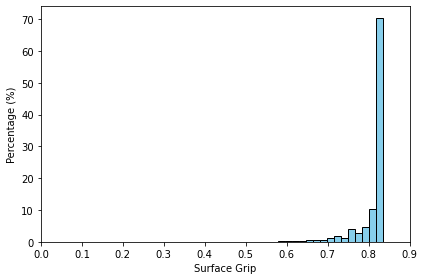

In [15]:
# === 分布可视化（清洗前） ===
# plt.figure(figsize=(8, 4))
# plt.hist(y, bins=50, color='skyblue', edgecolor='black')
# plt.xlabel("SurfaceGrip (y)")
# plt.ylabel("Count")
# plt.title("Histogram of SurfaceGrip before balancing")
# plt.tight_layout()
# plt.show()

weights = np.ones_like(y) / len(y) * 100

plt.figure()
plt.hist(y, bins=50,
         weights=weights,
         color='skyblue',
         edgecolor='black')
plt.xlabel("Surface Grip")
plt.ylabel("Percentage (%)")
plt.xlim(0,0.9)
# plt.title("Histogram of SurfaceGrip before balancing")
plt.tight_layout()
plt.savefig("before_balance.png", dpi=600)

X_seq: (13593, 11, 24) X_tab: (13593, 23) y: (13593,)


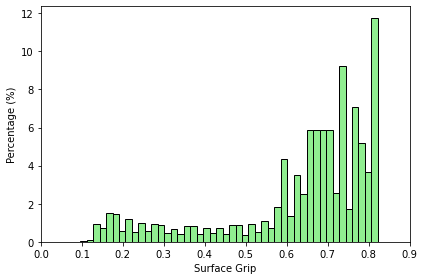

In [16]:
def balance_y_distribution(X_seq, X_tab, y, bins=50, max_per_bin=1000, random_state=42):
    np.random.seed(random_state)
    bin_edges = np.linspace(np.min(y), np.max(y), bins + 1)
    bin_indices = np.digitize(y, bins=bin_edges, right=True)

    selected_indices = []
    for b in range(1, bins + 1):
        bin_mask = bin_indices == b
        idx_in_bin = np.where(bin_mask)[0]
        if len(idx_in_bin) > max_per_bin:
            idx_selected = np.random.choice(idx_in_bin, size=max_per_bin, replace=False)
        else:
            idx_selected = idx_in_bin
        selected_indices.extend(idx_selected)

    selected_indices = np.array(selected_indices)
    return (
        X_seq[selected_indices],
        X_tab[selected_indices],
        y[selected_indices]
    )

# === 应用均衡 ===
X_seq_bal, X_tab_bal, y_bal = balance_y_distribution(X_seq, X_tab, y, bins=50, max_per_bin=1000)

weights_bal = np.ones_like(y_bal) / len(y_bal) * 100

plt.figure()
plt.hist(y_bal, bins=50,
         weights=weights_bal,
         color='lightgreen',
         edgecolor='black')
plt.xlabel("Surface Grip")
plt.ylabel("Percentage (%)")
# plt.title("Histogram of SurfaceGrip after balancing")
plt.xlim(0,0.9)
plt.tight_layout()
plt.savefig("after_balance.png", dpi=600)

# === Train-test split ===
X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_seq_bal, X_tab_bal, y_bal, test_size=0.2, random_state=42
)

# 最终维度确认
print("X_seq:", X_seq_train.shape, "X_tab:", X_tab_train.shape, "y:", y_train.shape)
